In [ ]:
!pip install keras-tuner imbalanced-learn shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = "/content/drive/MyDrive/Hilbot"
JSON_PATH = f"{DATA_DIR}/data.json"
CSV_PATH = f"{DATA_DIR}/HilData.csv"
GLOVE_PATH = f"{DATA_DIR}/glove.6B.200d.txt"
OUTPUT_DIR = f"{DATA_DIR}/outputs"

In [ ]:
import os, json, datetime

RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

BASE_DIR = "/content/drive/MyDrive/Hilbot"
OUTPUT_DIR = f"{BASE_DIR}/outputs/run_{RUN_ID}"

SUBDIRS = [
    "configs", "histories", "models", "metrics",
    "figures", "predictions", "artifacts", "summary_tables"
]

for s in SUBDIRS:
    os.makedirs(f"{OUTPUT_DIR}/{s}", exist_ok=True)

print("Experiment folder created at:", OUTPUT_DIR)

Experiment folder created at: /content/drive/MyDrive/Hilbot/outputs/run_20260427_074011


In [ ]:
EXPERIMENT_CONFIG = {
    "run_id": RUN_ID,
    "embedding_dim": 200,
    "maxlen": 200,
    "test_split": 0.15,
    "validation_split": 0.15,
    "batch_size": 32,
    "epochs": 200,
    "smote_k": 2,
    "random_states": [42, 100, 123, 2024, 2026],
    "models": [
        "LogReg", "SVM", "Conv1D", "LSTM",
        "TFIDF_ONLY", "GLOVE_ONLY", "HILBOT"
    ]
}

with open(f"{OUTPUT_DIR}/configs/config.json", "w") as f:
    json.dump(EXPERIMENT_CONFIG, f, indent=4)

print("Config saved.")

Config saved.


In [ ]:
import pandas as pd
import json
import os

JSON_PATH = f"{BASE_DIR}/data.json"
CSV_PATH = f"{BASE_DIR}/HilData.csv"

# Load JSON
with open(JSON_PATH, "r") as f:
    intents_data = json.load(f)

json_rows = []

for intent in intents_data["intents"]:
    tag = intent["tag"]
    patterns = intent.get("patterns", [])

    for pattern in patterns:
        if pattern.strip() != "":
            json_rows.append({
                "text": pattern,
                "label": tag,
                "source": "json"
            })

json_df = pd.DataFrame(json_rows)

# Load CSV
csv_df = pd.read_csv(CSV_PATH)

print("JSON columns:", json_df.columns)
print("CSV columns:", csv_df.columns)
print("JSON shape:", json_df.shape)
print("CSV shape:", csv_df.shape)

JSON columns: Index(['text', 'label', 'source'], dtype='object')
CSV columns: Index(['type', 'category', 'month', 'amount', 'year'], dtype='object')
JSON shape: (474, 3)
CSV shape: (912, 5)


In [ ]:
# Create text from CSV columns
csv_df["text"] = (
    csv_df["category"].astype(str) + " " +
    csv_df["month"].astype(str) + " " +
    csv_df["amount"].astype(str) + " " +
    csv_df["year"].astype(str)
)

# Use CSV type as label
csv_df["label"] = csv_df["type"].astype(str)
csv_df["source"] = "csv"

# Combine JSON + CSV
combined_df = pd.concat([
    json_df[["text", "label", "source"]],
    csv_df[["text", "label", "source"]]
], ignore_index=True)

print("Combined shape:", combined_df.shape)
print(combined_df.head())
print(combined_df["label"].value_counts())

Combined shape: (1386, 3)
               text     label source
0          Hi there  greeting   json
1  Is anyone there?  greeting   json
2               Hey  greeting   json
3              Hola  greeting   json
4             Hello  greeting   json
label
expense                        456
savings                        304
income                         152
current mood                    27
monthly savings                 22
savings overview                22
monthly income                  20
yearly income (category)        20
income overview                 20
yearly expense                  20
investment advice               19
goodbye                         19
expense overview                18
loan advice                     17
budget and saving tips          17
greeting                        16
concern                         16
monthly income (category)       15
monthly expense (category)      15
yearly expense (category)       15
yearly income                   15
yearly savi

In [ ]:
combined_df.to_csv(f"{OUTPUT_DIR}/artifacts/combined_raw_data.csv", index=False)

class_counts = combined_df["label"].value_counts()
class_counts.to_csv(f"{OUTPUT_DIR}/artifacts/class_distribution_raw.csv")

print("Saved combined data and raw class distribution.")

Saved combined data and raw class distribution.


In [ ]:
import re
import string
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from dateutil.parser import parse

nltk.download("wordnet")
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

SYNONYMS = {
    "spend": "expense",
    "spending": "expense",
    "outlay": "expense",
    "disbursement": "expense",
    "cost": "expense",
    "charge": "expense",
    "expenditure": "expense",
    "outgoings": "expense",
    "outflow": "expense",
    "save": "savings",
    "saving": "savings",
    "earn": "income",
    "earning": "income",
    "earnings": "income",
    "revenue": "income",
    "profit": "income",
    "gain": "income",
    "budgeting": "budget",
    "networth": "net worth",
    "liabilities": "debts",
    "debt": "liabilities",
    "cash": "money",
    "currency": "money",
    "funds": "money",
}

def recognize_date(text):
    try:
        dt = parse(text, fuzzy=True)
        return dt.strftime("%B %Y")
    except Exception:
        return text

def replace_synonyms(text):
    text = text.lower()
    for word, synonym in SYNONYMS.items():
        text = re.sub(rf"\b{re.escape(word)}\b", synonym, text)
    return text

def preprocess_text(text):
    text = str(text)
    text = recognize_date(text)
    text = replace_synonyms(text)
    exclude = set(string.punctuation) - {"$"}
    text = "".join(ch for ch in text if ch not in exclude)
    tokens = nltk.word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(tok.lower())
        for tok in tokens
        if tok.lower() not in stop_words
    ]
    return " ".join(tokens)

combined_df["clean_text"] = combined_df["text"].apply(preprocess_text)

combined_df.to_csv(f"{OUTPUT_DIR}/artifacts/clean_data.csv", index=False)

print(combined_df[["text", "clean_text", "label"]].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


               text clean_text     label
0          Hi there         hi  greeting
1  Is anyone there?     anyone  greeting
2               Hey        hey  greeting
3              Hola       hola  greeting
4             Hello      hello  greeting


In [ ]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test only
# This is safer because your smallest class has only 5 samples.
train_df, test_df = train_test_split(
    combined_df,
    test_size=0.20,
    random_state=42,
    stratify=combined_df["label"]
)

# Use part of training as validation internally during model.fit
train_df.to_csv(f"{OUTPUT_DIR}/artifacts/train_data.csv", index=False)
test_df.to_csv(f"{OUTPUT_DIR}/artifacts/test_data.csv", index=False)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

print("Train labels:", train_df["label"].nunique())
print("Test labels:", test_df["label"].nunique())

print("\nSmallest train classes:")
print(train_df["label"].value_counts().tail())

print("\nSmallest test classes:")
print(test_df["label"].value_counts().tail())

Train: (1108, 4)
Test: (278, 4)
Train labels: 33
Test labels: 33

Smallest train classes:
label
net worth                    10
emergency fund management    10
expense tracking tips         6
Retirement Planning tips      6
thanks                        4
Name: count, dtype: int64

Smallest test classes:
label
emergency fund management    2
net worth                    2
Retirement Planning tips     1
expense tracking tips        1
thanks                       1
Name: count, dtype: int64


In [ ]:
import pickle
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["label"])
y_test = encoder.transform(test_df["label"])

num_classes = len(encoder.classes_)
class_names = list(encoder.classes_)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

with open(f"{OUTPUT_DIR}/artifacts/label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

with open(f"{OUTPUT_DIR}/artifacts/class_names.json", "w") as f:
    json.dump(class_names, f, indent=4)

print("Number of classes:", num_classes)
print(class_names)

Number of classes: 33
['Guidance for Managing Debts', 'Retirement Planning tips', 'budget and saving tips', 'concern', 'current mood', 'emergency fund management', 'expense', 'expense overview', 'expense tracking tips', 'goodbye', 'greeting', 'income', 'income overview', 'investment advice', 'loan advice', 'monthly budget', 'monthly expense', 'monthly expense (category)', 'monthly income', 'monthly income (category)', 'monthly savings', 'monthly savings (category)', 'net worth', 'options', 'savings', 'savings overview', 'thanks', 'yearly expense', 'yearly expense (category)', 'yearly income', 'yearly income (category)', 'yearly savings', 'yearly savings (category)']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["clean_text"]).toarray()
X_test_tfidf = tfidf_vectorizer.transform(test_df["clean_text"]).toarray()

with open(f"{OUTPUT_DIR}/artifacts/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (1108, 431)
TF-IDF test shape: (278, 431)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 200

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["clean_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["clean_text"])
X_test_seq = tokenizer.texts_to_sequences(test_df["clean_text"])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size = len(tokenizer.word_index) + 1

with open(f"{OUTPUT_DIR}/artifacts/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Vocab size:", vocab_size)
print("Padded train shape:", X_train_pad.shape)
print("Padded test shape:", X_test_pad.shape)

Vocab size: 433
Padded train shape: (1108, 200)
Padded test shape: (278, 200)


In [ ]:
import numpy as np

GLOVE_PATH = f"{BASE_DIR}/glove.6B.200d.txt"
EMBEDDING_DIM = 200

def load_glove_vectors(glove_path):
    embeddings = {}
    with open(glove_path, "r", encoding="utf-8") as file:
        for line in file:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings[word] = vector
    return embeddings

embeddings = load_glove_vectors(GLOVE_PATH)

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

for word, idx in tokenizer.word_index.items():
    vector = embeddings.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMBEDDING_DIM,))

np.save(f"{OUTPUT_DIR}/artifacts/embedding_matrix.npy", embedding_matrix)

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (433, 200)


In [ ]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

all_metrics = []

def evaluate_and_save(model_name, y_true, y_pred, y_prob=None, seed=42):
    metrics = {
        "model": model_name,
        "seed": seed,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    all_metrics.append(metrics)

    pd.DataFrame([metrics]).to_csv(
        f"{OUTPUT_DIR}/metrics/{model_name}_seed_{seed}_metrics.csv",
        index=False
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report).transpose().to_csv(
        f"{OUTPUT_DIR}/metrics/{model_name}_seed_{seed}_classification_report.csv"
    )

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        f"{OUTPUT_DIR}/metrics/{model_name}_seed_{seed}_confusion_matrix.csv"
    )

    pred_df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred
    })

    if y_prob is not None:
        prob_df = pd.DataFrame(y_prob, columns=[f"prob_{c}" for c in class_names])
        pred_df = pd.concat([pred_df, prob_df], axis=1)

    pred_df.to_csv(
        f"{OUTPUT_DIR}/predictions/{model_name}_seed_{seed}_predictions.csv",
        index=False
    )

    print(model_name, metrics)
    return metrics


def save_history(history, model_name, seed=42):
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(
        f"{OUTPUT_DIR}/histories/{model_name}_seed_{seed}_history.csv",
        index=False
    )
    return hist_df


def save_learning_curves(history, model_name, seed=42):
    hist = pd.DataFrame(history.history)

    plt.figure()
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title(f"{model_name} Accuracy Curve")
    plt.savefig(
        f"{OUTPUT_DIR}/figures/{model_name}_seed_{seed}_accuracy_curve.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

    plt.figure()
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f"{model_name} Loss Curve")
    plt.savefig(
        f"{OUTPUT_DIR}/figures/{model_name}_seed_{seed}_loss_curve.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()


def save_sklearn_model(model, model_name, seed=42):
    with open(f"{OUTPUT_DIR}/models/{model_name}_seed_{seed}.pkl", "wb") as f:
        pickle.dump(model, f)


def save_keras_model(model, model_name, seed=42):
    model.save(f"{OUTPUT_DIR}/models/{model_name}_seed_{seed}.keras")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

SEED = 42

# Logistic Regression
logreg = LogisticRegression(
    max_iter=3000,
    random_state=SEED,
    class_weight="balanced"
)

logreg.fit(X_train_tfidf, y_train)
y_pred_logreg = logreg.predict(X_test_tfidf)
y_prob_logreg = logreg.predict_proba(X_test_tfidf)

save_sklearn_model(logreg, "LogisticRegression", SEED)
evaluate_and_save("LogisticRegression", y_test, y_pred_logreg, y_prob_logreg, SEED)


# Linear SVM with probability calibration
svm_base = LinearSVC(
    random_state=SEED,
    class_weight="balanced",
    max_iter=5000
)

svm = CalibratedClassifierCV(svm_base)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)
y_prob_svm = svm.predict_proba(X_test_tfidf)

save_sklearn_model(svm, "LinearSVM", SEED)
evaluate_and_save("LinearSVM", y_test, y_pred_svm, y_prob_svm, SEED)

LogisticRegression {'model': 'LogisticRegression', 'seed': 42, 'accuracy': 0.9172661870503597, 'precision_weighted': 0.9474480555415807, 'recall_weighted': 0.9172661870503597, 'f1_weighted': 0.9244406038997555}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


LinearSVM {'model': 'LinearSVM', 'seed': 42, 'accuracy': 0.9568345323741008, 'precision_weighted': 0.9596138757197009, 'recall_weighted': 0.9568345323741008, 'f1_weighted': 0.9541588952821258}


{'model': 'LinearSVM',
 'seed': 42,
 'accuracy': 0.9568345323741008,
 'precision_weighted': 0.9596138757197009,
 'recall_weighted': 0.9568345323741008,
 'f1_weighted': 0.9541588952821258}

In [ ]:
import random
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout,
    BatchNormalization, Activation, MaxPooling1D, concatenate, LSTM
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-6
)

In [ ]:
from tensorflow.keras.layers import SpatialDropout1D
def build_conv1d_model(vocab_size, embedding_dim, embedding_matrix, num_classes, max_len=200):
    seq_input = Input(shape=(max_len,), name="sequence_input")

    x = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(seq_input)

    x = SpatialDropout1D(0.3)(x)
    x = Conv1D(128, kernel_size=5, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = GlobalMaxPooling1D()(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=seq_input, outputs=output)
    model.compile(
        optimizer="rmsprop",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


SEED = 42
set_all_seeds(SEED)

conv1d_model = build_conv1d_model(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    embedding_matrix=embedding_matrix,
    num_classes=num_classes,
    max_len=MAX_LEN
)

history_conv1d = conv1d_model.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_prob_conv1d = conv1d_model.predict(X_test_pad)
y_pred_conv1d = np.argmax(y_prob_conv1d, axis=1)

save_keras_model(conv1d_model, "Conv1D", SEED)
save_history(history_conv1d, "Conv1D", SEED)
save_learning_curves(history_conv1d, "Conv1D", SEED)
evaluate_and_save("Conv1D", y_test, y_pred_conv1d, y_prob_conv1d, SEED)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - accuracy: 0.5324 - loss: 3.0356 - val_accuracy: 0.6766 - val_loss: 2.3663 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.6929 - loss: 1.1772 - val_accuracy: 0.7066 - val_loss: 1.8659 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.7492 - loss: 0.8940 - val_accuracy: 0.7545 - val_loss: 1.5147 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.7991 - loss: 0.7049 - val_accuracy: 0.8024 - val_loss: 1.1669 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.8353 - loss: 0.5856 - val_accuracy: 0.8144 - val_loss: 0.9720 - learning_rate: 0.0010
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.8650 - loss: 0.4468 - val_accuracy: 0.8144 - val_loss: 0.8195 - learning_rate: 0.0010
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.8937 - loss: 0.3

{'model': 'Conv1D',
 'seed': 42,
 'accuracy': 0.9280575539568345,
 'precision_weighted': 0.9368705035971222,
 'recall_weighted': 0.9280575539568345,
 'f1_weighted': 0.9248320823860392}

In [ ]:
def build_bilstm_model(vocab_size, embedding_dim, embedding_matrix, num_classes, max_len=200):
    seq_input = Input(shape=(max_len,), name="sequence_input")

    x = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True,   # allow fine-tuning
        mask_zero=True
    )(seq_input)

    x = SpatialDropout1D(0.2)(x)

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.0)
    )(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=seq_input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


SEED = 42
set_all_seeds(SEED)

bilstm_model = build_bilstm_model(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    embedding_matrix=embedding_matrix,
    num_classes=num_classes,
    max_len=MAX_LEN
)

history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_prob_bilstm = bilstm_model.predict(X_test_pad)
y_pred_bilstm = np.argmax(y_prob_bilstm, axis=1)

save_keras_model(bilstm_model, "BiLSTM", SEED)
save_history(history_bilstm, "BiLSTM", SEED)
save_learning_curves(history_bilstm, "BiLSTM", SEED)
evaluate_and_save("BiLSTM", y_test, y_pred_bilstm, y_prob_bilstm, SEED)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 589ms/step - accuracy: 0.4283 - loss: 2.5107 - val_accuracy: 0.6527 - val_loss: 1.4421 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 553ms/step - accuracy: 0.6780 - loss: 1.2206 - val_accuracy: 0.6946 - val_loss: 1.1924 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 537ms/step - accuracy: 0.7173 - loss: 1.0541 - val_accuracy: 0.6826 - val_loss: 1.0462 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 537ms/step - accuracy: 0.7545 - loss: 0.9005 - val_accuracy: 0.7725 - val_loss: 0.8577 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 536ms/step - accuracy: 0.7949 - loss: 0.7338 - val_accuracy: 0.8443 - val_loss: 0.6504 - learning_rate: 0.0010
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 572ms/step - accuracy: 0.8363 - loss: 0.6022 - val_accuracy: 0.8623 - val_loss: 0.6137 - learning_rate: 2.0000e-04
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 543ms/step - accuracy: 0.8618

{'model': 'BiLSTM',
 'seed': 42,
 'accuracy': 0.6546762589928058,
 'precision_weighted': 0.4815241875465145,
 'recall_weighted': 0.6546762589928058,
 'f1_weighted': 0.5449638310485471}

In [ ]:
def build_hilbot_model(
    vocab_size,
    embedding_dim,
    embedding_matrix,
    num_classes,
    input_tfidf_dim,
    max_len=200
):
    # Sequence / GloVe-CNN branch
    seq_input = Input(shape=(max_len,), name="sequence_input")

    x1 = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(seq_input)

    x1 = SpatialDropout1D(0.3)(x1)

    x1 = Conv1D(128, kernel_size=5, padding="same", kernel_regularizer=l2(0.001))(x1)
    x1 = BatchNormalization()(x1)
    x1 = Activation("relu")(x1)
    x1 = MaxPooling1D(pool_size=2)(x1)

    x1 = Conv1D(128, kernel_size=3, padding="same", kernel_regularizer=l2(0.001))(x1)
    x1 = BatchNormalization()(x1)
    x1 = Activation("relu")(x1)

    x1 = GlobalMaxPooling1D()(x1)

    # TF-IDF branch
    tfidf_input = Input(shape=(input_tfidf_dim,), name="tfidf_input")

    x2 = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(tfidf_input)
    x2 = Dropout(0.3)(x2)

    # Fusion
    merged = concatenate([x1, x2])

    x = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(merged)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=[seq_input, tfidf_input], outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


SEED = 42
set_all_seeds(SEED)

hilbot_model = build_hilbot_model(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    embedding_matrix=embedding_matrix,
    num_classes=num_classes,
    input_tfidf_dim=X_train_tfidf.shape[1],
    max_len=MAX_LEN
)

history_hilbot = hilbot_model.fit(
    [X_train_pad, X_train_tfidf],
    y_train_cat,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_prob_hilbot = hilbot_model.predict([X_test_pad, X_test_tfidf])
y_pred_hilbot = np.argmax(y_prob_hilbot, axis=1)

save_keras_model(hilbot_model, "Hilbot", SEED)
save_history(history_hilbot, "Hilbot", SEED)
save_learning_curves(history_hilbot, "Hilbot", SEED)
evaluate_and_save("Hilbot", y_test, y_pred_hilbot, y_prob_hilbot, SEED)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 245ms/step - accuracy: 0.5707 - loss: 2.4333 - val_accuracy: 0.6707 - val_loss: 2.9840 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step - accuracy: 0.7322 - loss: 1.5986 - val_accuracy: 0.4431 - val_loss: 3.0796 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.7821 - loss: 1.3063 - val_accuracy: 0.4491 - val_loss: 3.1528 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.8278 - loss: 1.0708 - val_accuracy: 0.3952 - val_loss: 3.0707 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.8618 - loss: 0.9023 - val_accuracy: 0.3832 - val_loss: 3.0256 - learning_rate: 0.0010
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.8969 - loss: 0.7664 - val_accuracy: 0.3832 - val_loss: 3.0611 - learning_rate: 2.0000e-04
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.9075 - los

{'model': 'Hilbot',
 'seed': 42,
 'accuracy': 0.6906474820143885,
 'precision_weighted': 0.6422711074034102,
 'recall_weighted': 0.6906474820143885,
 'f1_weighted': 0.6546085277012834}

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Split train into train_nn and val_nn explicitly
train_nn_df, val_nn_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["label"]
)

# Rebuild labels
y_train_nn = encoder.transform(train_nn_df["label"])
y_val_nn = encoder.transform(val_nn_df["label"])

y_train_nn_cat = to_categorical(y_train_nn, num_classes=num_classes)
y_val_nn_cat = to_categorical(y_val_nn, num_classes=num_classes)

# Rebuild TF-IDF
X_train_nn_tfidf = tfidf_vectorizer.transform(train_nn_df["clean_text"]).toarray()
X_val_nn_tfidf = tfidf_vectorizer.transform(val_nn_df["clean_text"]).toarray()

# Rebuild sequences
X_train_nn_seq = tokenizer.texts_to_sequences(train_nn_df["clean_text"])
X_val_nn_seq = tokenizer.texts_to_sequences(val_nn_df["clean_text"])

X_train_nn_pad = pad_sequences(X_train_nn_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_nn_pad = pad_sequences(X_val_nn_seq, maxlen=MAX_LEN, padding="post", truncating="post")

# Class weights
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_nn),
    y=y_train_nn
)

class_weights_dict = {i: cw[i] for i in range(len(cw))}

print("Train NN:", X_train_nn_pad.shape, X_train_nn_tfidf.shape)
print("Val NN:", X_val_nn_pad.shape, X_val_nn_tfidf.shape)
print("Class weights ready.")

Train NN: (941, 200) (941, 431)
Val NN: (167, 200) (167, 431)
Class weights ready.


In [ ]:
def build_hilbot_v2(
    vocab_size,
    embedding_dim,
    embedding_matrix,
    num_classes,
    input_tfidf_dim,
    max_len=200
):
    # GloVe / CNN branch
    seq_input = Input(shape=(max_len,), name="sequence_input")

    x1 = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    )(seq_input)

    x1 = SpatialDropout1D(0.2)(x1)

    x1 = Conv1D(128, kernel_size=3, padding="same", activation="relu")(x1)
    x1 = GlobalMaxPooling1D()(x1)

    x1 = Dense(64, activation="relu")(x1)
    x1 = Dropout(0.25)(x1)

    # TF-IDF branch
    tfidf_input = Input(shape=(input_tfidf_dim,), name="tfidf_input")

    x2 = Dense(256, activation="relu")(tfidf_input)
    x2 = Dropout(0.25)(x2)

    x2 = Dense(128, activation="relu")(x2)
    x2 = Dropout(0.25)(x2)

    # Fusion
    merged = concatenate([x1, x2])

    x = Dense(128, activation="relu")(merged)
    x = Dropout(0.3)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=[seq_input, tfidf_input], outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


SEED = 42
set_all_seeds(SEED)

hilbot_v2 = build_hilbot_v2(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    embedding_matrix=embedding_matrix,
    num_classes=num_classes,
    input_tfidf_dim=X_train_tfidf.shape[1],
    max_len=MAX_LEN
)

history_hilbot_v2 = hilbot_v2.fit(
    [X_train_nn_pad, X_train_nn_tfidf],
    y_train_nn_cat,
    validation_data=([X_val_nn_pad, X_val_nn_tfidf], y_val_nn_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict,
    verbose=1
)

y_prob_hilbot_v2 = hilbot_v2.predict([X_test_pad, X_test_tfidf])
y_pred_hilbot_v2 = np.argmax(y_prob_hilbot_v2, axis=1)

save_keras_model(hilbot_v2, "Hilbot_V2", SEED)
save_history(history_hilbot_v2, "Hilbot_V2", SEED)
save_learning_curves(history_hilbot_v2, "Hilbot_V2", SEED)
evaluate_and_save("Hilbot_V2", y_test, y_pred_hilbot_v2, y_prob_hilbot_v2, SEED)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.0595 - loss: 3.4879 - val_accuracy: 0.2874 - val_loss: 3.2779 - learning_rate: 5.0000e-04
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.1775 - loss: 3.3526 - val_accuracy: 0.4072 - val_loss: 2.9884 - learning_rate: 5.0000e-04
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.3571 - loss: 3.1307 - val_accuracy: 0.4970 - val_loss: 2.2015 - learning_rate: 5.0000e-04
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.4357 - loss: 2.8600 - val_accuracy: 0.7365 - val_loss: 1.5012 - learning_rate: 5.0000e-04
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.5367 - loss: 2.4175 - val_accuracy: 0.8383 - val_loss: 1.0977 - learning_rate: 5.0000e-04
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.6217 - loss: 2.1658 - val_accuracy: 0.8383 - val_loss: 1.0483 - learning_rate: 1.0000e-04
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accura

{'model': 'Hilbot_V2',
 'seed': 42,
 'accuracy': 0.2697841726618705,
 'precision_weighted': 0.5871276625849796,
 'recall_weighted': 0.2697841726618705,
 'f1_weighted': 0.3240582421438652}

In [ ]:
pred_counts = pd.Series(y_pred_hilbot_v2).map(
    dict(enumerate(class_names))
).value_counts()

true_counts = pd.Series(y_test).map(
    dict(enumerate(class_names))
).value_counts()

diagnostic_df = pd.DataFrame({
    "true_test_count": true_counts,
    "predicted_count": pred_counts
}).fillna(0).astype(int)

diagnostic_df.to_csv(f"{OUTPUT_DIR}/metrics/Hilbot_V2_prediction_distribution.csv")

diagnostic_df

,true_test_count,predicted_count
Guidance for Managing Debts,2,0
Retirement Planning tips,1,0
budget and saving tips,3,0
concern,3,0
current mood,6,0
emergency fund management,2,0
expense,92,41
expense overview,4,0
expense tracking tips,1,1
goodbye,4,5


In [ ]:
def build_hilbot_v3(
    vocab_size,
    embedding_dim,
    embedding_matrix,
    num_classes,
    input_tfidf_dim,
    max_len=200
):
    # GloVe-CNN branch
    seq_input = Input(shape=(max_len,), name="sequence_input")

    x1 = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(seq_input)

    x1 = SpatialDropout1D(0.15)(x1)
    x1 = Conv1D(64, kernel_size=3, padding="same", activation="relu")(x1)
    x1 = GlobalMaxPooling1D()(x1)
    x1 = Dense(64, activation="relu")(x1)
    x1 = Dropout(0.2)(x1)

    # TF-IDF branch
    tfidf_input = Input(shape=(input_tfidf_dim,), name="tfidf_input")

    x2 = Dense(256, activation="relu")(tfidf_input)
    x2 = Dropout(0.2)(x2)
    x2 = Dense(128, activation="relu")(x2)
    x2 = Dropout(0.2)(x2)

    # Fusion
    merged = concatenate([x1, x2])

    x = Dense(128, activation="relu")(merged)
    x = Dropout(0.25)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=[seq_input, tfidf_input], outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


SEED = 42
set_all_seeds(SEED)

hilbot_v3 = build_hilbot_v3(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    embedding_matrix=embedding_matrix,
    num_classes=num_classes,
    input_tfidf_dim=X_train_tfidf.shape[1],
    max_len=MAX_LEN
)

history_hilbot_v3 = hilbot_v3.fit(
    [X_train_nn_pad, X_train_nn_tfidf],
    y_train_nn_cat,
    validation_data=([X_val_nn_pad, X_val_nn_tfidf], y_val_nn_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_prob_hilbot_v3 = hilbot_v3.predict([X_test_pad, X_test_tfidf])
y_pred_hilbot_v3 = np.argmax(y_prob_hilbot_v3, axis=1)

save_keras_model(hilbot_v3, "Hilbot_V3", SEED)
save_history(history_hilbot_v3, "Hilbot_V3", SEED)
save_learning_curves(history_hilbot_v3, "Hilbot_V3", SEED)
evaluate_and_save("Hilbot_V3", y_test, y_pred_hilbot_v3, y_prob_hilbot_v3, SEED)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.3390 - loss: 2.4069 - val_accuracy: 0.6168 - val_loss: 1.5651 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5898 - loss: 1.4265 - val_accuracy: 0.6946 - val_loss: 1.1686 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6993 - loss: 1.1233 - val_accuracy: 0.7485 - val_loss: 1.0046 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7481 - loss: 0.9337 - val_accuracy: 0.7904 - val_loss: 0.7782 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7938 - loss: 0.7131 - val_accuracy: 0.8383 - val_loss: 0.5854 - learning_rate: 0.0010
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8448 - loss: 0.5540 - val_accuracy: 0.8683 - val_loss: 0.5359 - learning_rate: 2.0000e-04
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8555 - loss: 0.5

{'model': 'Hilbot_V3',
 'seed': 42,
 'accuracy': 0.5827338129496403,
 'precision_weighted': 0.4526919870748704,
 'recall_weighted': 0.5827338129496403,
 'f1_weighted': 0.4668648824301286}

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FIG_DIR = f"{OUTPUT_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

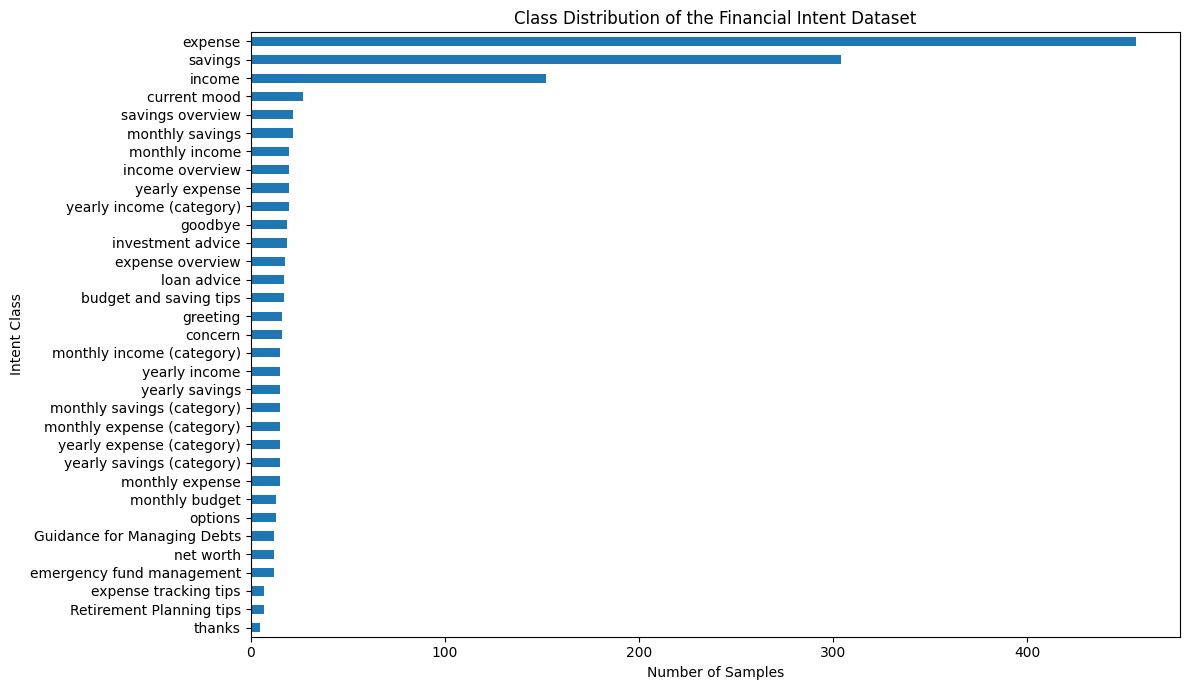

In [ ]:
class_counts = combined_df["label"].value_counts()

plt.figure(figsize=(12, 7))
class_counts.sort_values().plot(kind="barh")
plt.xlabel("Number of Samples")
plt.ylabel("Intent Class")
plt.title("Class Distribution of the Financial Intent Dataset")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/figure_1_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

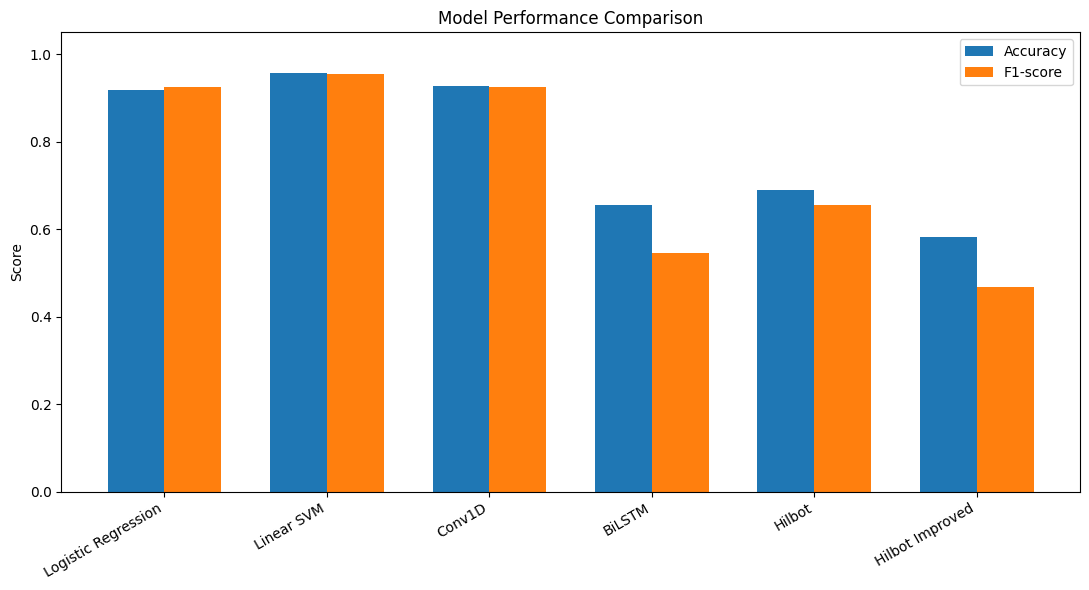

In [ ]:
results_df = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": 0.9173, "F1-score": 0.9244},
    {"Model": "Linear SVM", "Accuracy": 0.9568, "F1-score": 0.9542},
    {"Model": "Conv1D", "Accuracy": 0.9281, "F1-score": 0.9248},
    {"Model": "BiLSTM", "Accuracy": 0.6547, "F1-score": 0.5450},
    {"Model": "Hilbot", "Accuracy": 0.6906, "F1-score": 0.6546},
    {"Model": "Hilbot Improved", "Accuracy": 0.5827, "F1-score": 0.4669},
])

x = np.arange(len(results_df["Model"]))
width = 0.35

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, results_df["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, results_df["F1-score"], width, label="F1-score")
plt.xticks(x, results_df["Model"], rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/figure_2_model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

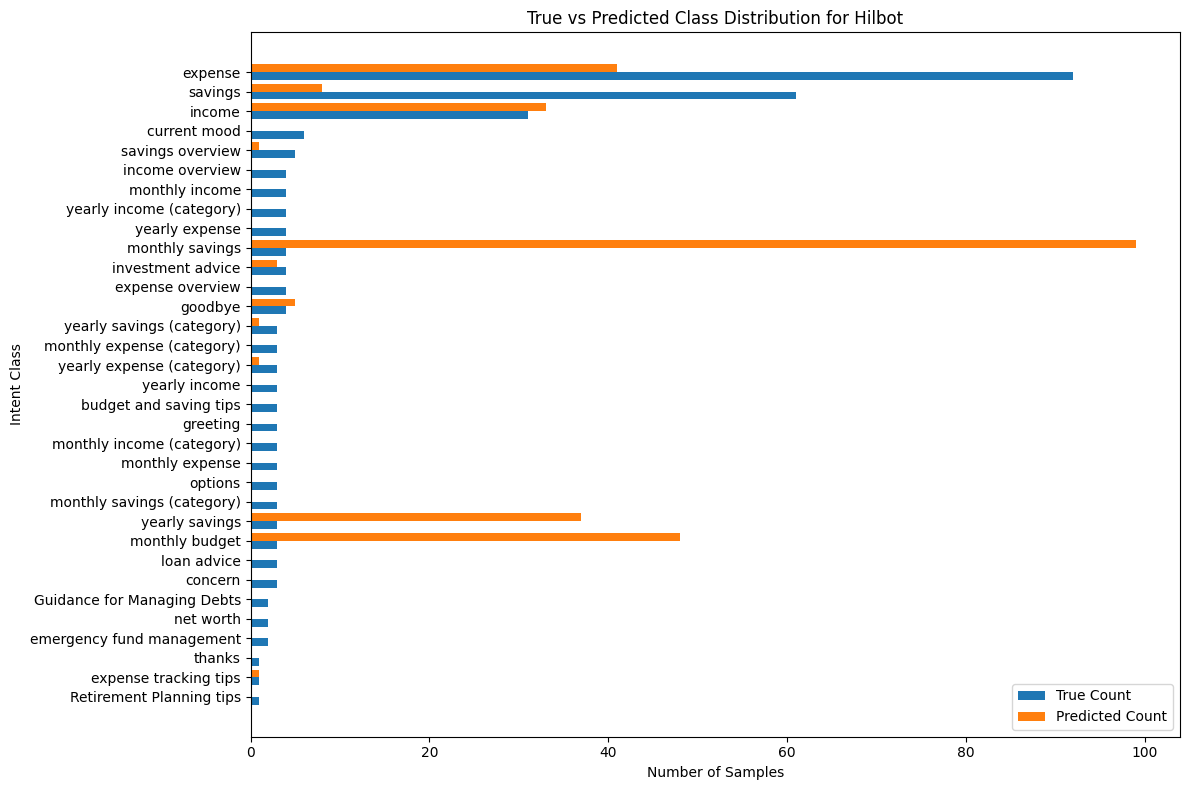

In [ ]:
diagnostic_df_sorted = diagnostic_df.sort_values("true_test_count", ascending=True)

plt.figure(figsize=(12, 8))
y = np.arange(len(diagnostic_df_sorted.index))

plt.barh(y - 0.2, diagnostic_df_sorted["true_test_count"], height=0.4, label="True Count")
plt.barh(y + 0.2, diagnostic_df_sorted["predicted_count"], height=0.4, label="Predicted Count")

plt.yticks(y, diagnostic_df_sorted.index)
plt.xlabel("Number of Samples")
plt.ylabel("Intent Class")
plt.title("True vs Predicted Class Distribution for Hilbot")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/figure_3_hilbot_prediction_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [ ]:
svm_preds = svm_model.predict(X_test_tfidf)

<Figure size 900x800 with 0 Axes>

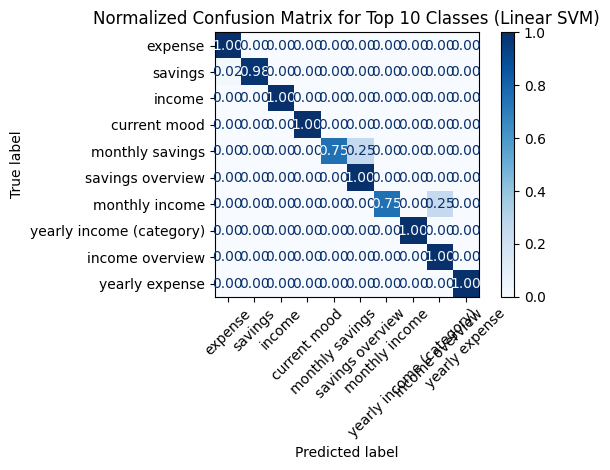

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os

FIG_DIR = f"{OUTPUT_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# top 10 most frequent classes
top_classes = list(combined_df["label"].value_counts().head(10).index)

# convert numeric labels to class names
y_test_names = np.array([class_names[i] for i in y_test])
y_pred_names = np.array([class_names[i] for i in svm_preds])

# keep only true labels in top 10
mask = np.isin(y_test_names, top_classes)

y_test_top = y_test_names[mask]
y_pred_top = y_pred_names[mask]

# force confusion matrix to only use top 10 labels
cm_top = confusion_matrix(
    y_test_top,
    y_pred_top,
    labels=top_classes,
    normalize="true"
)

plt.figure(figsize=(9, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_top,
    display_labels=top_classes
)
disp.plot(xticks_rotation=45, cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix for Top 10 Classes (Linear SVM)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/figure_4_confusion_matrix_top10_svm.png", dpi=300, bbox_inches="tight")
plt.show()

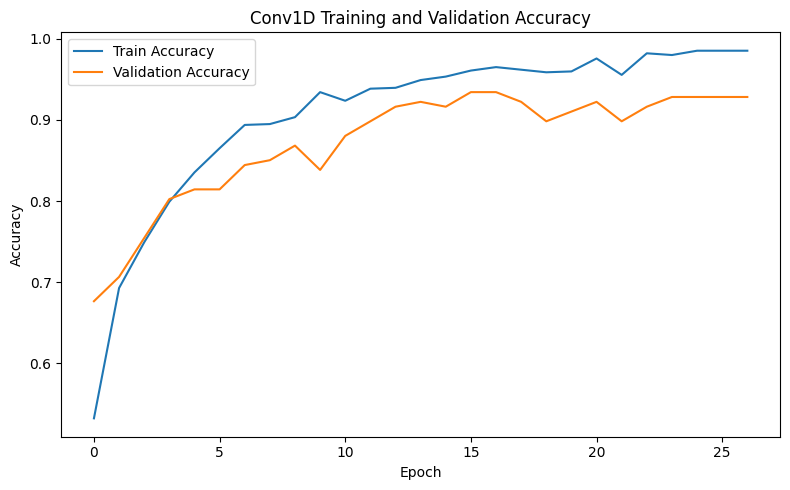

In [ ]:
hist = history_conv1d.history

plt.figure(figsize=(8,5))
plt.plot(hist["accuracy"], label="Train Accuracy")
plt.plot(hist["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Conv1D Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/figure_5_conv1d_training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

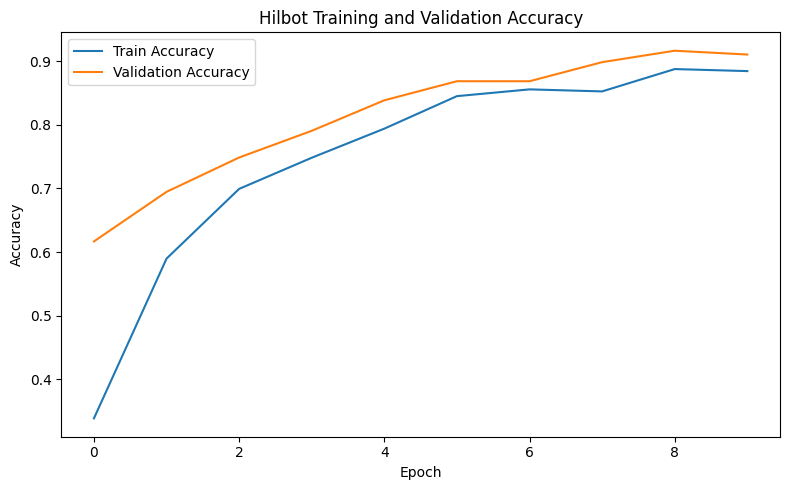

In [ ]:
hist = history_hilbot_v3.history

plt.figure(figsize=(8,5))
plt.plot(hist["accuracy"], label="Train Accuracy")
plt.plot(hist["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Hilbot Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/figure_6_hilbot_training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

ValueError: The number of FixedLocator locations (11), usually from a call to set_ticks, does not match the number of labels (10).

<Figure size 800x800 with 0 Axes>

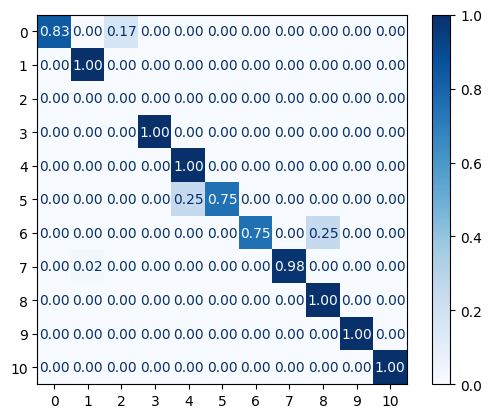

In [ ]:
# Get top 10 most frequent classes
top_classes = combined_df["label"].value_counts().head(10).index

# Filter test indices
mask = [class_names[y] in top_classes for y in y_test]

y_test_top = np.array(y_test)[mask]
y_pred_top = np.array(svm_preds)[mask]

# Map to reduced labels
top_class_names = list(top_classes)

cm_top = confusion_matrix(y_test_top, y_pred_top, normalize='true')

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_top, display_labels=top_class_names)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")

plt.title("Confusion Matrix (Top 10 Classes - SVM)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/figure_4_confusion_matrix_top10.png", dpi=300)
plt.show()

ValueError: The number of FixedLocator locations (11), usually from a call to set_ticks, does not match the number of labels (10).

<Figure size 800x800 with 0 Axes>

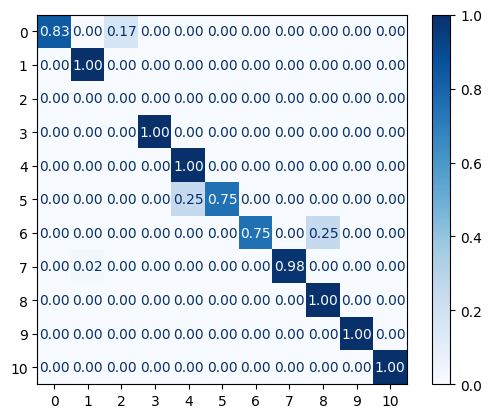

In [ ]:
# Get top 10 most frequent classes
top_classes = combined_df["label"].value_counts().head(10).index

# Filter test indices
mask = [class_names[y] in top_classes for y in y_test]

y_test_top = np.array(y_test)[mask]
y_pred_top = np.array(svm_preds)[mask]

# Map to reduced labels
top_class_names = list(top_classes)

cm_top = confusion_matrix(y_test_top, y_pred_top, normalize='true')

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_top, display_labels=top_class_names)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")

plt.title("Confusion Matrix (Top 10 Classes - SVM)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/figure_4_confusion_matrix_top10.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, svm_preds))

Accuracy: 0.9496402877697842


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.savefig(f"{FIG_DIR}/figure_5_training_curve.png", dpi=300)
plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
diagnostic_df_sorted = diagnostic_df.sort_values("true_test_count", ascending=True)

plt.figure(figsize=(12, 8))
y = np.arange(len(diagnostic_df_sorted.index))

plt.barh(y - 0.2, diagnostic_df_sorted["true_test_count"], height=0.4, label="True Count")
plt.barh(y + 0.2, diagnostic_df_sorted["predicted_count"], height=0.4, label="Predicted Count")

plt.yticks(y, diagnostic_df_sorted.index)
plt.xlabel("Number of Samples")
plt.ylabel("Intent Class")
plt.title("True vs Predicted Class Distribution for Hilbot")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/figure_3_hilbot_prediction_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
class_counts = combined_df['label'].value_counts()

train_counts = train_df['label'].value_counts()
test_counts = test_df['label'].value_counts()

dataset_table = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
}).fillna(0).astype(int)

dataset_table

,Train,Test
label,,
Guidance for Managing Debts,10,2
Retirement Planning tips,6,1
budget and saving tips,14,3
concern,13,3
current mood,21,6
emergency fund management,10,2
expense,364,92
expense overview,14,4
expense tracking tips,6,1


In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='hilbot_architecture.png', show_shapes=True)

NameError: name 'model' is not defined

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_preds))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       0.83      0.83      0.83         6
           5       0.00      0.00      0.00         2
           6       0.96      1.00      0.98        92
           7       1.00      0.75      0.86         4
           8       1.00      1.00      1.00         1
           9       1.00      0.50      0.67         4
          10       0.67      0.67      0.67         3
          11       1.00      1.00      1.00        31
          12       0.67      1.00      0.80         4
          13       1.00      0.75      0.86         4
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       1.00      1.00      1.00         3
          17       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
scores = []

for seed in [42, 52, 62, 72, 82]:
    svm = LinearSVC(random_state=seed)
    svm.fit(X_train_tfidf, y_train)
    preds = svm.predict(X_test_tfidf)
    f1 = f1_score(y_test, preds, average='weighted')
    scores.append(f1)

import numpy as np
print(np.mean(scores), np.std(scores))

SyntaxError: unexpected character after line continuation character (697615533.py, line 1)

In [ ]:
scores = []

for seed in [42, 52, 62, 72, 82]:
    svm = LinearSVC(random_state=seed)
    svm.fit(X_train_tfidf, y_train)
    preds = svm.predict(X_test_tfidf)
    f1 = f1_score(y_test, preds, average='weighted')
    scores.append(f1)

import numpy as np
print(np.mean(scores), np.std(scores))

0.9443688903444091 1.1102230246251565e-16


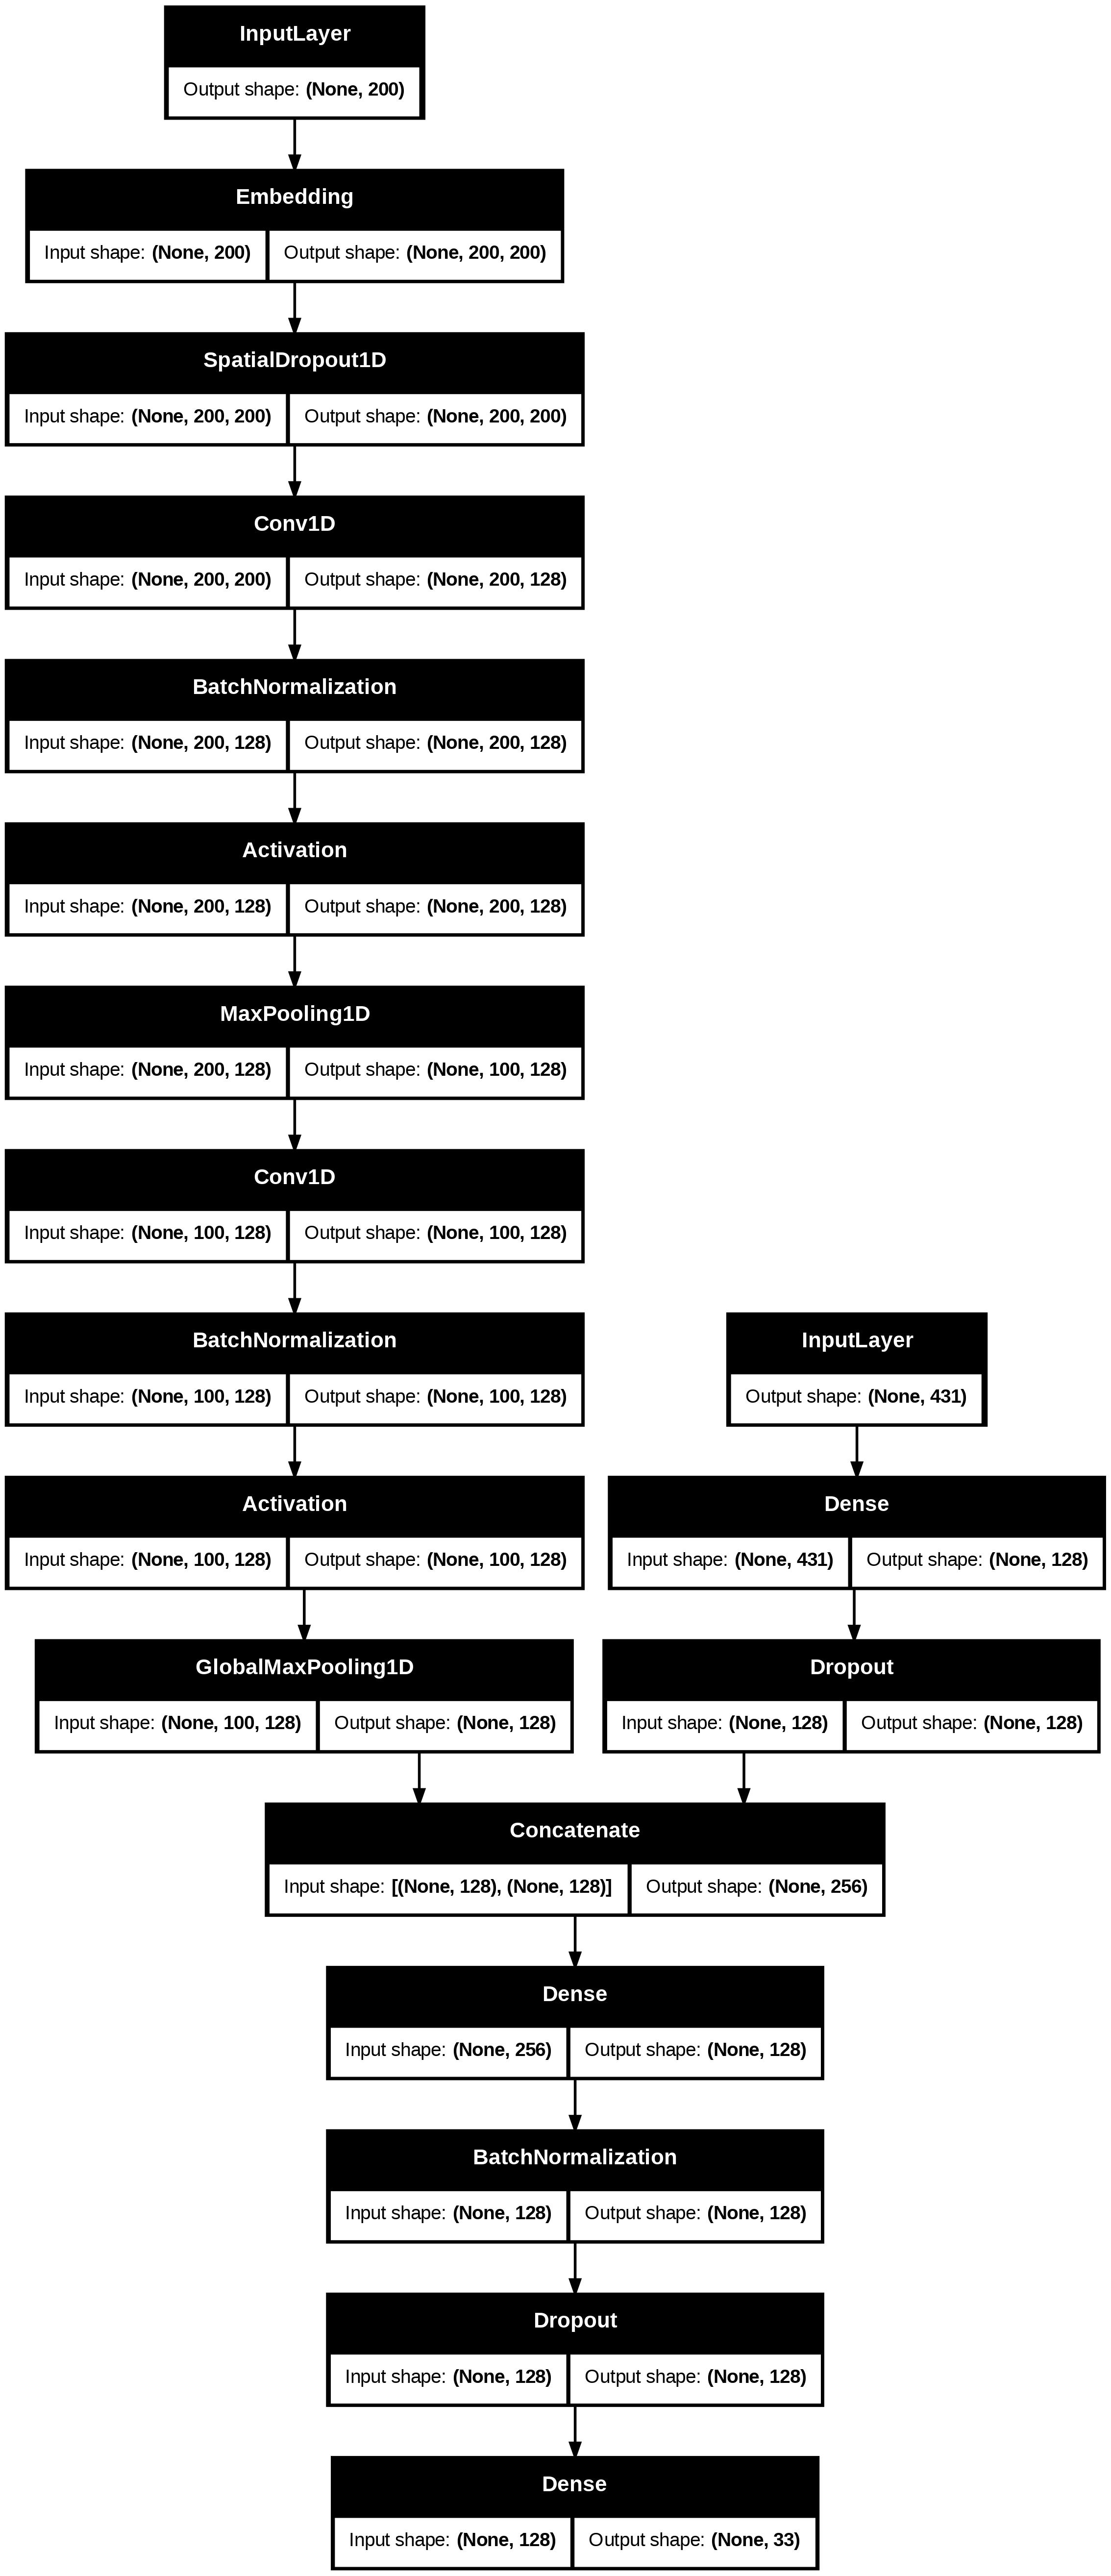

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(hilbot_model, to_file='hilbot_architecture.png', show_shapes=True)
